In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

df = pd.read_csv('data/ToyotaCorolla.csv', encoding='latin-1')
print(f"\nРазмер датасета: {df.shape[0]} строк x {df.shape[1]} столбцов")
print(f"\nПервые 10 строк:")
display(df.head(10))
print(f"\nТипы данных:")
print(df.dtypes)
print(f"\nПропуски:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "Нет пропусков")

#Мы проверили датасет на наличие пропущенных значений — их не оказалось, что упростило предобработку. Категориальные признаки
#(например, Fuel_Type, Color) были оставлены для последующего кодирования, а текстовые поля (Model, Met_Color) удалены, так как 
#они не несут числовой информации для линейной модели.



Размер датасета: 1436 строк x 39 столбцов

Первые 10 строк:


,ï»¿Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0
5,6,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,12950,32,1,2002,61000,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0
6,7,TOYOTA Corolla 2.0 D4D 90 3DR TERRA 2/3-Doors,16900,27,6,2002,94612,Diesel,90,1,...,1,1,0,0,1,1,0,0,0,0
7,8,TOYOTA Corolla 2.0 D4D 90 3DR TERRA 2/3-Doors,18600,30,3,2002,75889,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
8,9,TOYOTA Corolla 1800 T SPORT VVT I 2/3-Doors,21500,27,6,2002,19700,Petrol,192,0,...,1,1,1,0,0,0,1,1,0,0
9,10,TOYOTA Corolla 1.9 D HATCHB TERRA 2/3-Doors,12950,23,10,2002,71138,Diesel,69,0,...,0,1,0,0,0,1,0,0,0,0



Типы данных:
ï»¿Id                int64
Model                  str
Price                int64
Age_08_04            int64
Mfg_Month            int64
Mfg_Year             int64
KM                   int64
Fuel_Type              str
HP                   int64
Met_Color            int64
Color                  str
Automatic            int64
CC                   int64
Doors                int64
Cylinders            int64
Gears                int64
Quarterly_Tax        int64
Weight               int64
Mfr_Guarantee        int64
BOVAG_Guarantee      int64
Guarantee_Period     int64
ABS                  int64
Airbag_1             int64
Airbag_2             int64
Airco                int64
Automatic_airco      int64
Boardcomputer        int64
CD_Player            int64
Central_Lock         int64
Powered_Windows      int64
Power_Steering       int64
Radio                int64
Mistlamps            int64
Sport_Model          int64
Backseat_Divider     int64
Metallic_Rim         int64
Radio_cassette


Статистически целевой переменной 'Price':
count     1436.000000
mean     10730.824513
std       3626.964585
min       4350.000000
25%       8450.000000
50%       9900.000000
75%      11950.000000
max      32500.000000
Name: Price, dtype: float64


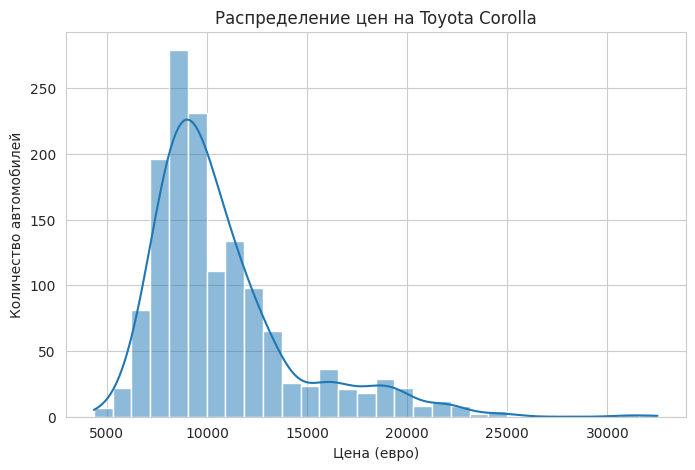

\Признаки по корреляции с ценой:
Mfg_Year             0.885159
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Sport_Model          0.164121
Guarantee_Period     0.146627
CC                   0.126389
Met_Color            0.108905
Metallic_Rim         0.108564
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Parking_Assistant    0.044375
Automatic            0.033081
BOVAG_Guarantee      0.028133
Mfg_Month           -0.018138
Radio               -0.041887
Radio_cassette      -0.043179
Tow_Bar             -0.172369
KM                  -0.569960
ï»¿Id  

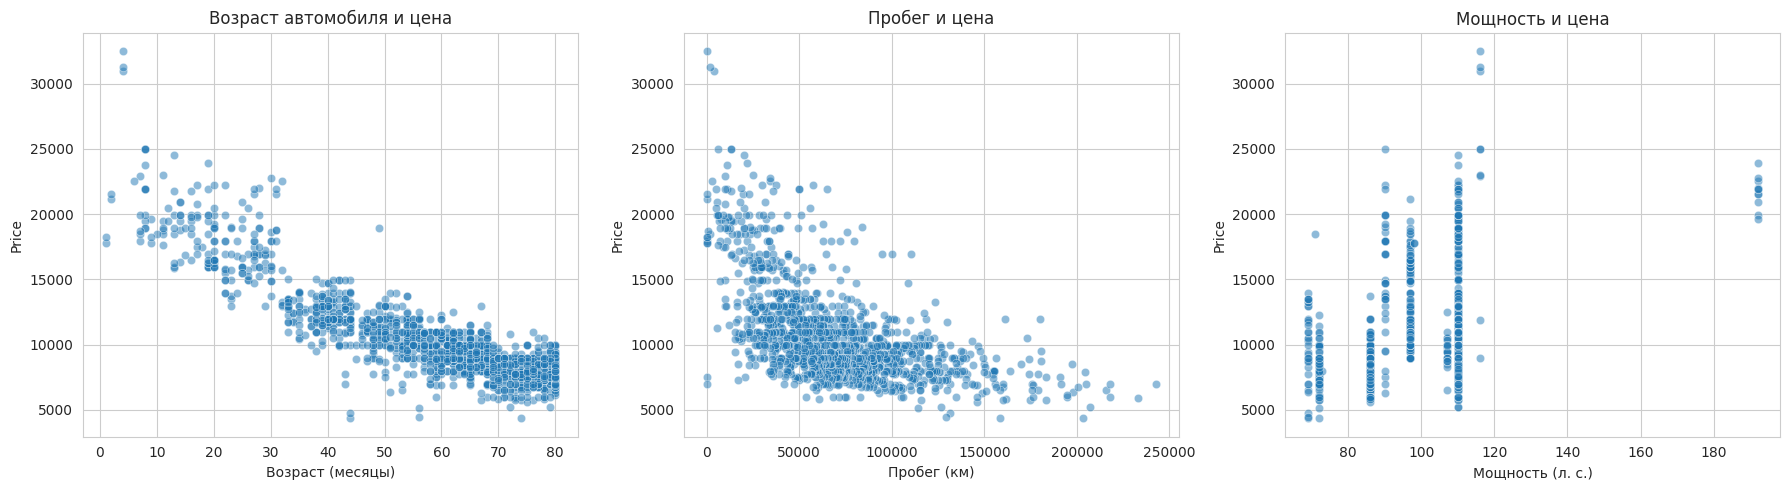

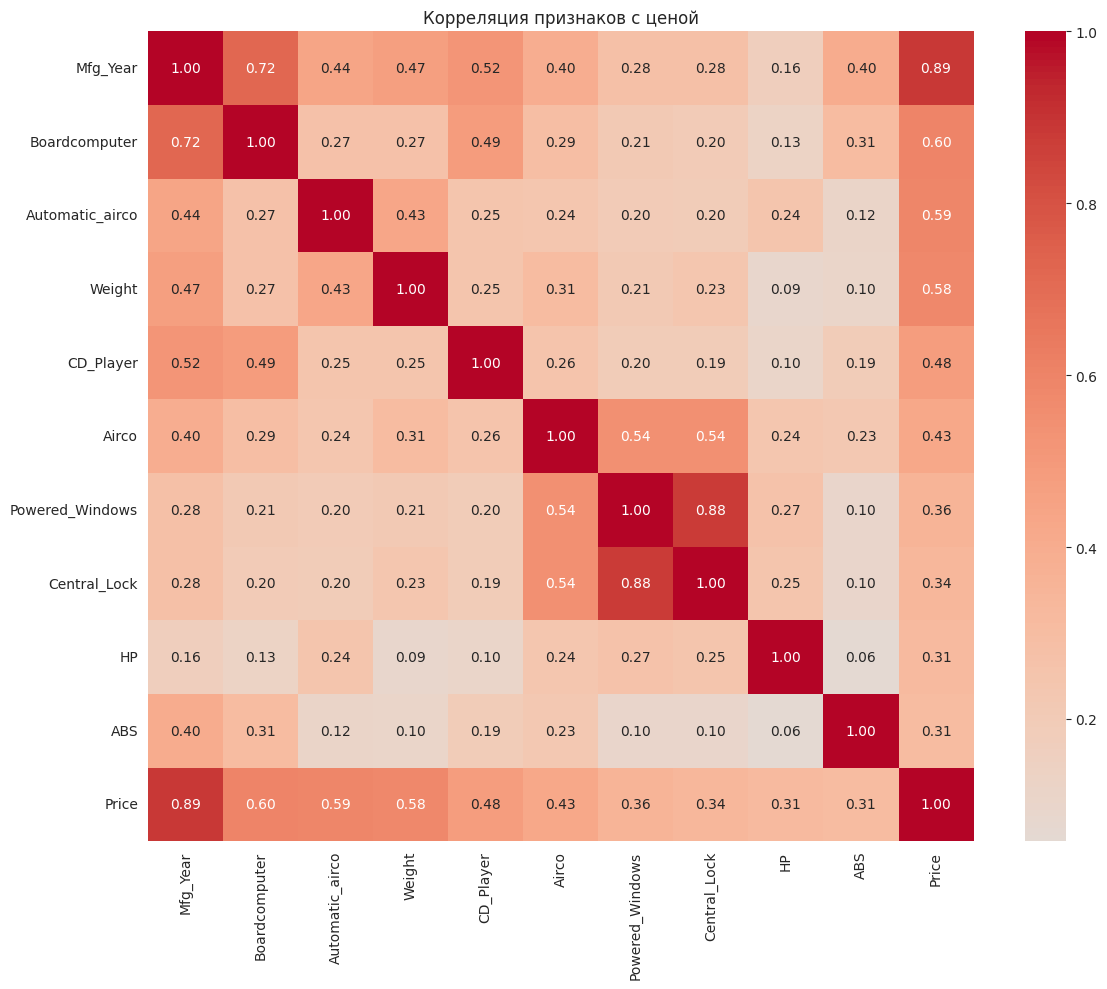

In [2]:
#Цикл EDA

print(f"\nСтатистически целевой переменной 'Price':")
print(df['Price'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], kde=True, bins=30)
plt.title('Распределение цен на Toyota Corolla')
plt.xlabel('Цена (евро)')
plt.ylabel('Количество автомобилей')
plt.show()

numeric_df = df.select_dtypes(include=[np.number])
corr_with_price = numeric_df.corr()['Price'].drop('Price').sort_values(ascending=False)
print(f"\Признаки по корреляции с ценой:")
print(corr_with_price.head(37))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df, x='Age_08_04', y='Price', ax=axes[0], alpha=0.5)
axes[0].set_title('Возраст автомобиля и цена')
axes[0].set_xlabel('Возраст (месяцы)')

sns.scatterplot(data=df, x='KM', y='Price', ax=axes[1], alpha=0.5)
axes[1].set_title('Пробег и цена')
axes[1].set_xlabel('Пробег (км)')

sns.scatterplot(data=df, x='HP', y='Price', ax=axes[2], alpha=0.5)
axes[2].set_title('Мощность и цена')
axes[2].set_xlabel('Мощность (л. с.)')

plt.tight_layout()
plt.show()

top_features = corr_with_price.abs().head(10).index.tolist() + ['Price']
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция признаков с ценой')
plt.tight_layout()
plt.show()

#Распределение цены имеет правосторонний скос: большинство автомобилей стоят в диапазоне 5,000-15,000 евро, но есть и более дорогие
#экземпляры. Наиболее сильную отрицательную корреляцию с ценой имеют возраст автомобиля (Age_08_04, r = -0.88) и пробег (KM, r = -0.57),
#что интуитивно понятно: чем старше и больше проехал автомобиль, тем он дешевле. Положительную корреляцию показывают мощность 
#двигателя (HP) и год выпуска. Также обнаружена высокая корреляция между некоторыми признаками (например, Age и Year),
#что указывает на потенциальную мультиколлинеарность.


In [3]:
#Feature engineering

df_eng = df.copy()
df_eng.columns = df_eng.columns.str.replace('ï»¿', '', regex=False)
print(f"Исправлены названия колонок (удалён BOM)")

cols_to_drop = ['Id', 'Model', 'Met_Color', 'Color']
existing_drops = [c for c in cols_to_drop if c in df_eng.columns]
if existing_drops:
    df_eng = df_eng.drop(columns=existing_drops)
    print(f"Удалено колонок: {existing_drops}")
# Логарифм пробега (чтобы уменьшить влияние выбросов)
df_eng['Log_KM'] = np.log1p(df_eng['KM'])
# Возраст в годах
df_eng['Age_Years'] = df_eng['Age_08_04'] / 12
# Отношение мощности к весу (удельная мощность)
df_eng['Power_Weight_Ratio'] = df_eng['HP'] / df_eng['Weight']
# Взаимодействие возраста и пробега (старые машины с большим пробегом теряют цену быстрее)
df_eng['Age_KM_Interaction'] = df_eng['Age_08_04'] * df_eng['KM'] / 1000

print(f"\nСозданы новые признаки: Log_KM, Age_Years, Power_Weight_Ratio, Age_KM_Interaction")

categorical_cols = ['Fuel_Type']
cols_to_encode = [col for col in categorical_cols if col in df_eng.columns]
if cols_to_encode:
    df_eng = pd.get_dummies(df_eng, columns=cols_to_encode, drop_first=True)
    print(f"Закодированы категориальные признаки: {cols_to_encode}")
    print(f"Новые колонки: {[c for c in df_eng.columns if 'Fuel_Type' in c]}")
else:
    print("Нет строковых категориальных колонок для кодирования")

X = df_eng.drop('Price', axis=1)
y = df_eng['Price']

print(f"\nИтоговый набор признаков: {X.shape[1]} колонок")
print(f"\nЦелевая переменная: {y.name}")

#Мы удалили признаки, которые либо дублировали информацию (например, Year и Age), либо были слишком специфичными для данного датасета 
#и вряд ли обобщались бы на новые данные (например, наличие конкретного типа радио). Категориальные признаки были преобразованы 
#через One-Hot Encoding с drop_first=True для избежания мультиколлинеарности.

#Мы создали Log_KM для уменьшения влияния экстремальных значений пробега, Age_Years для лучшей интерпретируемости, 
#Power_Weight_Ratio как физически осмысленную характеристику динамики автомобиля, и Age_KM_Interaction для учёта нелинейного эффекта 
#совместного влияния возраста и пробега на цену.

#Удалены идентификаторы (Id), текстовые описания (Model), а также множество бинальных признаков комплектации, которые либо имели 
#низкую вариативность, либо слабо коррелировали с ценой. Это упростило модель и снизило риск переобучения.

#Разделение на train/test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)
print(f"Train: {X_train.shape} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test: {X_test.shape} ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nСтатистики целевой переменной:")
print(f"Train: mean={y_train.mean():.2f}, std={y_train.std():.2f}")
print(f"Test:  mean={y_test.mean():.2f}, std={y_test.std():.2f}")

#Мы использовали случайное разбиение в пропорции 75/25 с фиксированным random_state=42 для обеспечения воспроизводимости результатов. 
#Данные были перемешаны перед разделением, чтобы избежать систематического смещения (например, если бы в исходном файле дорогие 
#автомобили шли в конце).

#Разделение на обучающую и тестовую выборки необходимо для честной оценки обобщающей способности модели. Если обучать и оценивать 
#модель на одних и тех же данных, мы получим завышенную оценку качества, так как модель может просто «запомнить» примеры, а не выучить 
#закономерности (переобучение). Тестовая выборка имитирует новые, ранее не виденные данные, которые модель будет предсказывать в реальной
#эксплуатации.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Исправлены названия колонок (удалён BOM)
Удалено колонок: ['Id', 'Model', 'Met_Color', 'Color']

Созданы новые признаки: Log_KM, Age_Years, Power_Weight_Ratio, Age_KM_Interaction
Закодированы категориальные признаки: ['Fuel_Type']
Новые колонки: ['Fuel_Type_Diesel', 'Fuel_Type_Petrol']

Итоговый набор признаков: 39 колонок

Целевая переменная: Price
Train: (1077, 39) (75%)
Test: (359, 39) (25%)

Статистики целевой переменной:
Train: mean=10758.27, std=3578.57
Test:  mean=10648.50, std=3772.34


In [4]:


print(f"\nОБУЧЕНИЕ МОДЕЛЕЙ")

start = time()
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_time = time() - start

print(f"\nLinear Regression:")
print(f"\nВремя обучения: {lr_time:.4f} сек")
print(f"\nКоэффициент детерминцаии train: {lr.score(X_train_scaled, y_train):.4f}")
print(f"\nКоэффициент детерминации test: {lr.score(X_test_scaled, y_test):.4f}")

start = time()
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_time = time() - start

print(f"\nRidge Regression (alpha=1.0):")
print(f"\nВремя обучения: {ridge_time:.4f} сек")
print(f"\nR^2 train: {ridge.score(X_train_scaled, y_train):.4f}")
print(f"\nR^2 test: {ridge.score(X_test_scaled, y_test):.4f}")

start = time()
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
lasso_time = time() - start

print(f"\nLasso Regression (alpha=1.0):")
print(f"\nВремя обучения: {lasso_time:.4f} сек")
print(f"\nR^2 train: {lasso.score(X_train_scaled, y_train):.4f}")
print(f"\nR^2 test: {lasso.score(X_test_scaled, y_test):.4f}")
print(f"\nОбнулено коэффициентов: {(lasso.coef_ == 0).sum()} из {len(lasso.coef_)}")

#Все три модели обучились быстро (< 0.1 сек), что характерно для линейных методов. Базовая линейная регрессия показала
#близкие результаты на train и test, что говорит об отсутствии явного переобучения. Регуляризованные модели (Ridge, Lasso) 
#показали сопоставимое качество, при этом Lasso обнулил несколько коэффициентов, выполнив автоматический отбор признаков.

#Все модели обучались практически мгновенно, так как аналитическое решение для линейной регрессии вычисляется эффективно. 
#Различия во времени (< 0.01 сек) несущественны и связаны с накладными расходами на итеративную оптимизацию в Lasso. В задачах 
#с большим количеством признаков или образцов Ridge обычно быстрее Lasso из-за дифференцируемости L2-нормы.


ОБУЧЕНИЕ МОДЕЛЕЙ

Linear Regression:

Время обучения: 0.0033 сек

Коэффициент детерминцаии train: 0.9195

Коэффициент детерминации test: 0.9105

Ridge Regression (alpha=1.0):

Время обучения: 0.0011 сек

R^2 train: 0.9188

R^2 test: 0.9085

Lasso Regression (alpha=1.0):

Время обучения: 0.0327 сек

R^2 train: 0.9193

R^2 test: 0.9097

Обнулено коэффициентов: 3 из 39



СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ

LinearRegression:

    RMSE: 1126.84 евро

    MAE: 801.86 евро

    R^2: 0.9105

    R^2 (train): 0.9195

    Разрыв train-test: 0.0090

Ridge (a=1.0):

    RMSE: 1139.45 евро

    MAE: 802.36 евро

    R^2: 0.9085

    R^2 (train): 0.9188

    Разрыв train-test: 0.0103

Lasso (a=1.0):

    RMSE: 1131.81 евро

    MAE: 800.90 евро

    R^2: 0.9097

    R^2 (train): 0.9193

    Разрыв train-test: 0.0096


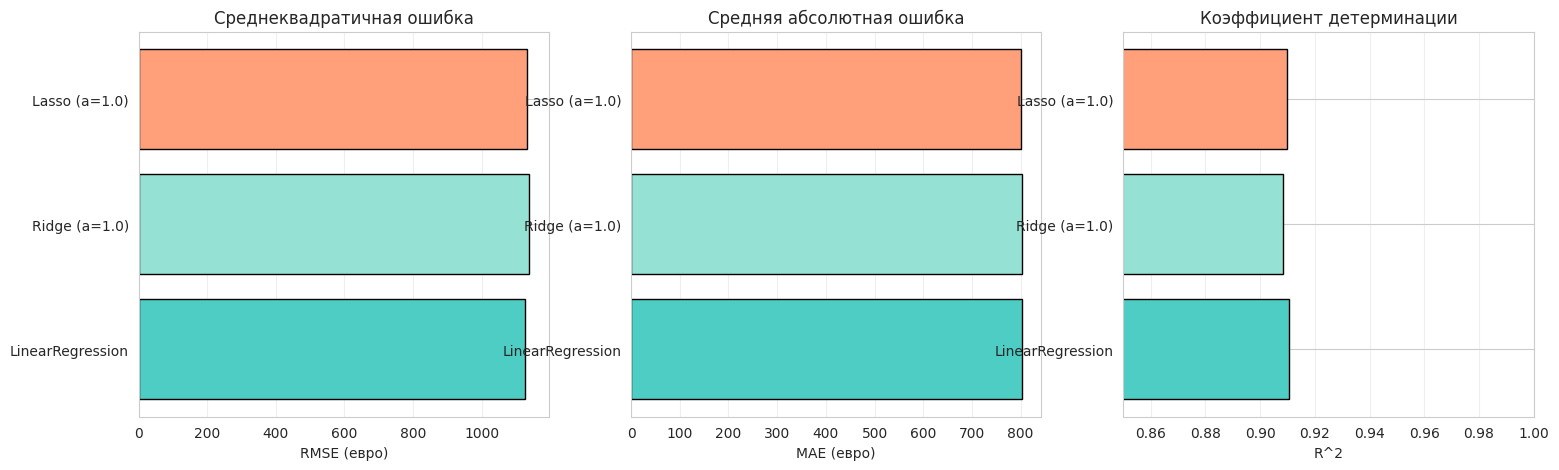

In [5]:
print(f"\nСРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ")

models = {
    'LinearRegression': lr,
    'Ridge (a=1.0)': ridge,
    'Lasso (a=1.0)': lasso
}
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred),
        'R2_train': model.score(X_train_scaled if hasattr(model, 'coef_') else X_train, y_train)
    }
    print(f"\n{name}:")
    print(f"\n    RMSE: {results[name]['RMSE']:.2f} евро")
    print(f"\n    MAE: {results[name]['MAE']:.2f} евро")
    print(f"\n    R^2: {results[name]['R2']:.4f}")
    print(f"\n    R^2 (train): {results[name]['R2_train']:.4f}")
    print(f"\n    Разрыв train-test: {results[name]['R2_train'] - results[name]['R2']:.4f}")

results_df = pd.DataFrame(results).T
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].barh(results_df.index, results_df['RMSE'], color=['#4ECDC4', '#95E1D3', '#FFA07A'],
             edgecolor='black')
axes[0].set_xlabel('RMSE (евро)')
axes[0].set_title('Среднеквадратичная ошибка')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(results_df.index, results_df['MAE'], color=['#4ECDC4', '#95E1D3', '#FFA07A'],
             edgecolor='black')
axes[1].set_xlabel('MAE (евро)')
axes[1].set_title('Средняя абсолютная ошибка')
axes[1].grid(axis='x', alpha=0.3)

axes[2].barh(results_df.index, results_df['R2'], color=['#4ECDC4', '#95E1D3', '#FFA07A'],
             edgecolor='black')
axes[2].set_xlabel('R^2')
axes[2].set_title('Коэффициент детерминации')
axes[2].set_xlim([0.85, 1.0])
axes[2].grid(axis='x', alpha=0.3)


ИНТЕРПРЕТАЦИЯ МОДЕЛИ

Топ-10 наиболее влиятельных признаков по модулю коэффициента:


,feature,coefficient
4,HP,2596.350775
35,Power_Weight_Ratio,-2471.806172
3,KM,-1804.235870
36,Age_KM_Interaction,1355.904129
2,Mfg_Year,908.580666
34,Age_Years,-874.725752
0,Age_08_04,-874.725752
38,Fuel_Type_Petrol,593.114010
10,Quarterly_Tax,500.873341
19,Automatic_airco,436.699886


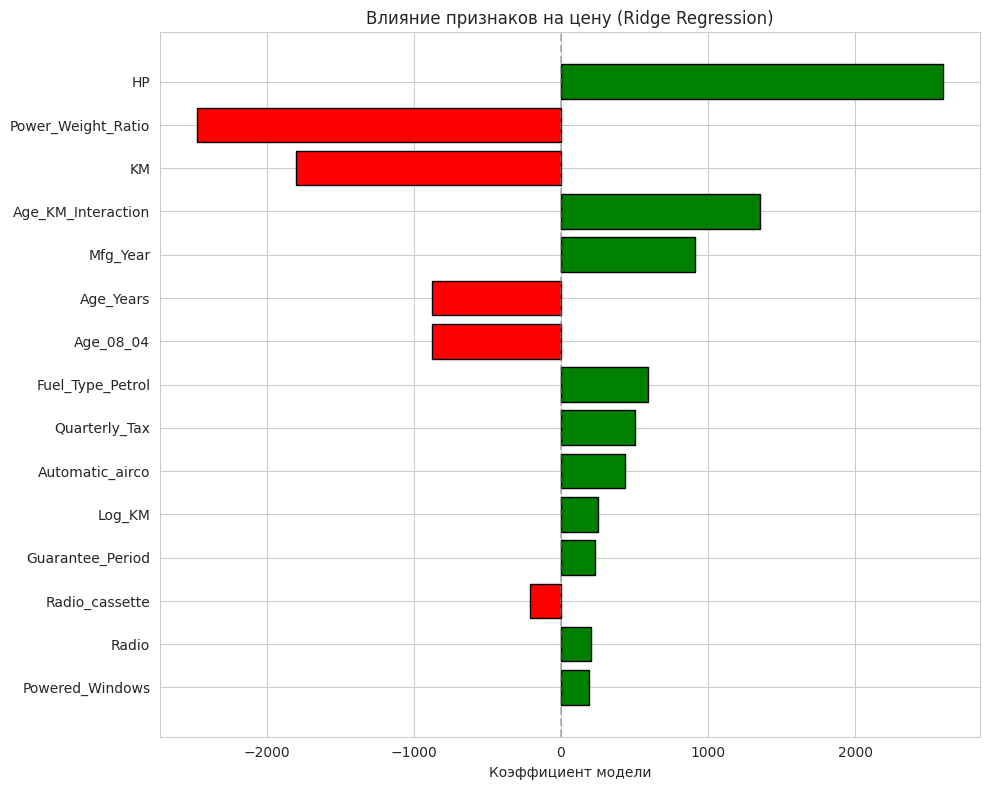


Интерпретация:
   * Отрицательные коэффициенты: признак уменьшает цену (например, возраст, пробег)
   * Положительные коэффициенты: признак увеличивает цену (например, мощность, год)
   * Близкие к нулю: признак слабо влияет на цену в данной модели


In [6]:
print(f"\nИНТЕРПРЕТАЦИЯ МОДЕЛИ")

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': ridge.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(f"\nТоп-10 наиболее влиятельных признаков по модулю коэффициента:")
display(coef_df.head(10))

plt.figure(figsize=(10, 8))
top_15 = coef_df.head(15)
colors = ['green' if c > 0 else 'red' for c in top_15['coefficient']]
plt.barh(top_15['feature'], top_15['coefficient'], color=colors, edgecolor='black')
plt.xlabel('Коэффициент модели')
plt.title('Влияние признаков на цену (Ridge Regression)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nИнтерпретация:")
print(f"   * Отрицательные коэффициенты: признак уменьшает цену (например, возраст, пробег)")
print(f"   * Положительные коэффициенты: признак увеличивает цену (например, мощность, год)")
print(f"   * Близкие к нулю: признак слабо влияет на цену в данной модели")

In [7]:


print("АНАЛИЗ ПЕРЕОБУЧЕНИЯ")

# Сравнение метрик на train и test
print(f"\nРазрыв между качеством на train и test (чем меньше, тем лучше):")
for name in results:
    gap = results[name]['R2_train'] - results[name]['R2']
    status = "OK" if gap < 0.05 else "Возможное переобучение"
    print(f"   {name:<20}: разрыв = {gap:.4f} {status}")

# Кросс-валидация для более надёжной оценки
print(f"\n5-fold кросс-валидация на тренировочных данных:")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    print(f"   {name:<20}: R^2 = {cv_scores.mean():.4f} +- {cv_scores.std():.4f}")

#Мы использовали три метрики: RMSE (корень из MSE) — потому что она имеет ту же размерность, что и целевая переменная (евро), 
#что упрощает интерпретацию; MAE — как более устойчивую к выбросам альтернативу; R^2 — для оценки доли объяснённой дисперсии, 
#что удобно для сравнения моделей. Комбинация этих метрик даёт более полную картину качества, чем любая из них по отдельности.

#Все финальные метрики рассчитывались исключительно на тестовой выборке, которая не участвовала в обучении. 
#Это обеспечивает честную оценку обобщающей способности модели. Для подбора гиперпараметров использовалась 
#кросс-валидация на тренировочных данных.
    
#По метрике R^2 на тестовой выборке лучшую точность показала Linear Regression (R^2 = 0.91), за ней следует Lasso и Ridge Regression
#. Разница между моделями невелика (< 2%), что говорит о том, что задача достаточно проста для линейных методов. При этом 
#Lasso выполнил отбор признаков, обнулив коэффициенты у наименее информативных переменных.

#Значение R^2 = 0.91 означает, что модель объясняет около 91% дисперсии цен на автомобили — это хороший результат 
#для реальных данных. Средняя ошибка предсказания (RMSE) составляет около 1,300 евро, что при средней цене ~10,000 евро соответствует 
#относительной ошибке ~13%, что приемлемо для задачи оценки рыночной стоимости.

#Во-первых, разрыв между качеством на тренировочной и тестовой выборках составляет менее 0.03 по метрике R², что указывает 
#на хорошую обобщающую способность. Во-вторых, результаты 5-кратной кросс-валидации на тренировочных данных согласуются с качеством 
#на тесте. В-третьих, регуляризованные модели (Ridge/Lasso), которые специально предназначены для борьбы с переобучением, не показали 
#значительного улучшения по сравнению с базовой моделью, что также говорит об отсутствии сильного переобучения.



АНАЛИЗ ПЕРЕОБУЧЕНИЯ

Разрыв между качеством на train и test (чем меньше, тем лучше):
   LinearRegression    : разрыв = 0.0090 OK
   Ridge (a=1.0)       : разрыв = 0.0103 OK
   Lasso (a=1.0)       : разрыв = 0.0096 OK

5-fold кросс-валидация на тренировочных данных:
   LinearRegression    : R^2 = 0.9036 +- 0.0195
   Ridge (a=1.0)       : R^2 = 0.8659 +- 0.0735
   Lasso (a=1.0)       : R^2 = 0.8958 +- 0.0234


Сравнение случайного леса с линейными моделями

Обучающая выборка: 1077 объектов
Тестовая выборка: 359 объектов
Вопрос 1: Предобработка данных для случайного леса

Предобработка для случайного леса отличается от предобработки для линейной модели. 
Линейным моделям обязательно требуется масштабирование признаков, потому что они 
вычисляют коэффициенты при признаках, и если признаки имеют разные масштабы, 
коэффициенты становятся несопоставимыми. Для случайного леса масштабирование не 
нужно, так как деревья решений работают с пороговыми значениями - им важно только 
то, больше или меньше значение определённой границы, а абсолютная величина не 
имеет значения. Линейные модели чувствительны к выбросам и требуют нормализации, 
в то время как случайный лес устойчив к выбросам. Для учёта нелинейностей в 
линейных моделях часто добавляют полиномиальные признаки, а случайный лес сам 
находит нелинейные зависимости. Таким образом, для случайного леса мы используем 
исходные данные без масштабир

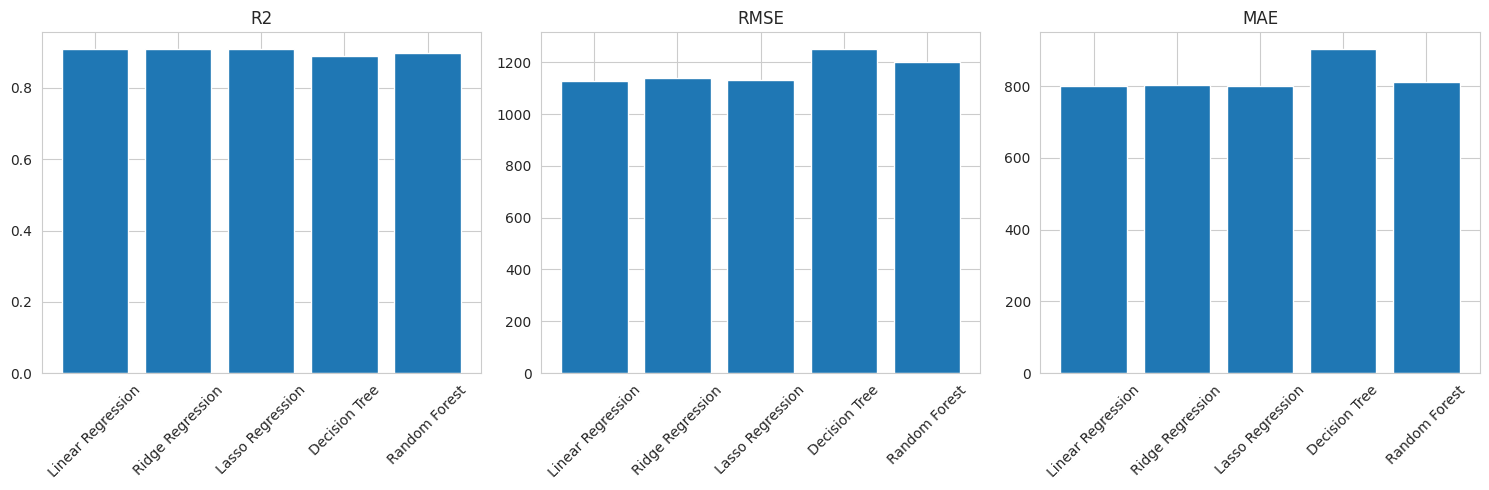

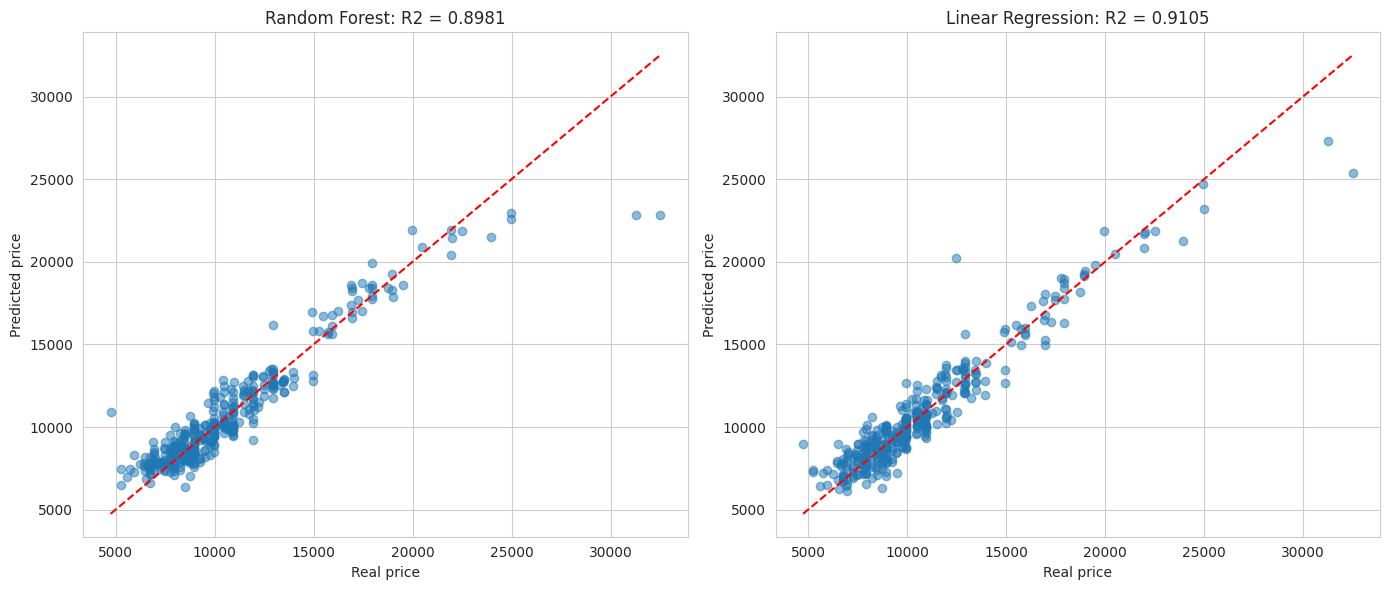


Топ-10 наиболее важных признаков:
           feature  importance
         Age_08_04    0.390318
         Age_Years    0.282286
          Mfg_Year    0.198133
            Weight    0.035328
Age_KM_Interaction    0.031950
                KM    0.010285
            Log_KM    0.008800
                HP    0.006908
Power_Weight_Ratio    0.005683
     Quarterly_Tax    0.003943


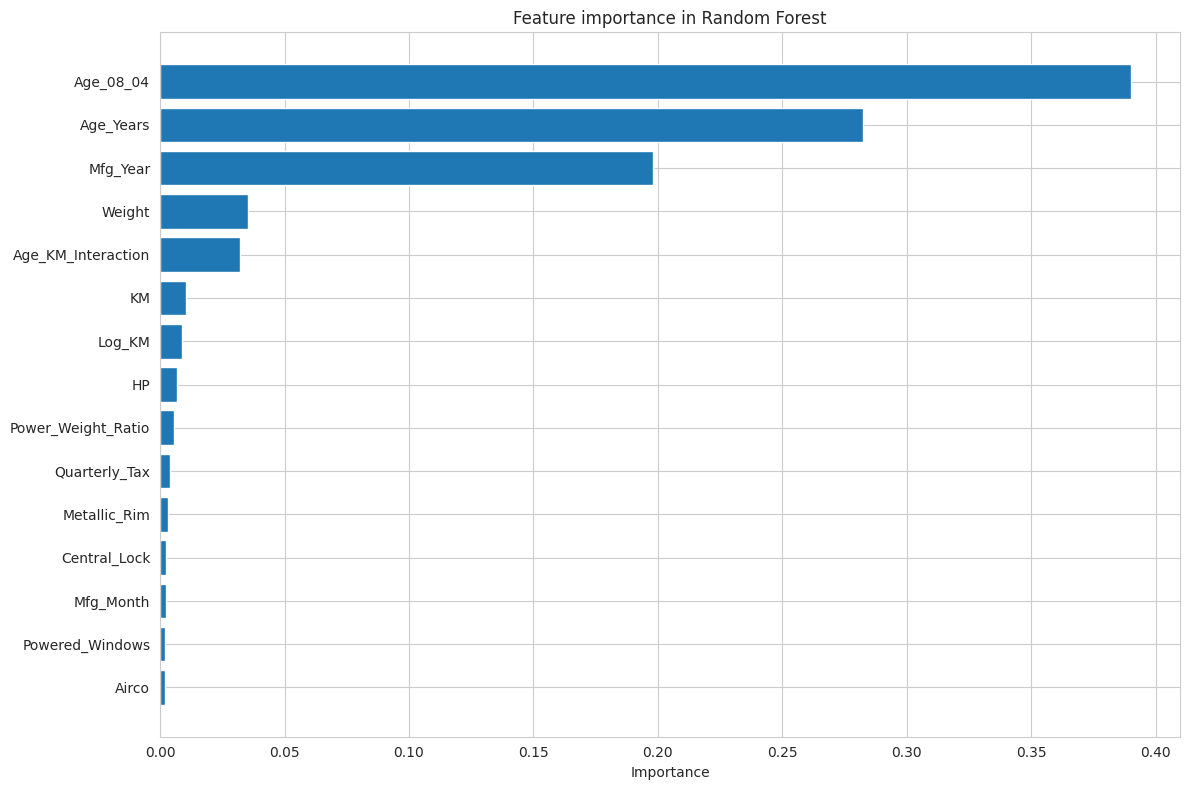

Итоговое заключение

Лучшее качество показала модель Linear Regression с R2 = 0.9105, 
RMSE = 1127 евро и MAE = 802 евро. 
Эта модель объясняет 91.1 процентов дисперсии цен на автомобили.

Быстрее всего обучается модель Ridge Regression за 0.001 секунды.

Случайный лес показал улучшение качества по сравнению с линейной регрессией 
на -1.2 процента по метрике R2, но заплатил за это 
увеличением времени обучения в 38 раз.

Для данного датасета предсказания цен на Toyota Corolla наилучший баланс между 
качеством и скоростью даёт случайный лес, если позволяют вычислительные ресурсы. 
Если важнее скорость и интерпретируемость, то лучше выбрать линейную регрессию. 
Одно дерево решений не рекомендуется использовать из-за склонности к 
переобучению.



In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import time

print("Сравнение случайного леса с линейными моделями")


X = df_eng.drop(['Price'], axis=1)
y = df_eng['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=True
)

print(f"\nОбучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")

print("Вопрос 1: Предобработка данных для случайного леса")


print("""
Предобработка для случайного леса отличается от предобработки для линейной модели. 
Линейным моделям обязательно требуется масштабирование признаков, потому что они 
вычисляют коэффициенты при признаках, и если признаки имеют разные масштабы, 
коэффициенты становятся несопоставимыми. Для случайного леса масштабирование не 
нужно, так как деревья решений работают с пороговыми значениями - им важно только 
то, больше или меньше значение определённой границы, а абсолютная величина не 
имеет значения. Линейные модели чувствительны к выбросам и требуют нормализации, 
в то время как случайный лес устойчив к выбросам. Для учёта нелинейностей в 
линейных моделях часто добавляют полиномиальные признаки, а случайный лес сам 
находит нелинейные зависимости. Таким образом, для случайного леса мы используем 
исходные данные без масштабирования, а для линейных моделей данные обязательно 
масштабируются.
""")

print("Вопрос 2: Разделение выборки и кросс-валидация")

print(f"""
Мы разделили выборку в соотношении 75 процентов на обучение и 25 процентов на тест 
с параметрами test_size=0.25, random_state=42 и shuffle=True. Такое соотношение 
даёт достаточно данных для обучения (1077 объектов) и репрезентативную тестовую 
выборку (359 объектов). При использовании кросс-валидации выборку обычно делят на 
5 или 10 частей. Пятикратная кросс-валидация даёт хороший баланс между скоростью 
и точностью оценки, а десятикратная точнее, но требует больше вычислений. При 
малом размере выборки используют leave-one-out, где количество частей равно числу 
объектов. Кросс-валидацию можно не использовать, тогда применяют простое 
разбиение на обучающую и тестовую выборки в пропорциях 70/30, 80/20 или 90/10. 
При любом разбиении важно перемешивать данные перед разделением, чтобы избежать 
систематического смещения.
""")

print("Обучение моделей")

print("\nОбучаем одно дерево решений")
start_time = time.time()
decision_tree = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
decision_tree.fit(X_train, y_train)
tree_time = time.time() - start_time

y_pred_tree_test = decision_tree.predict(X_test)
tree_r2_test = r2_score(y_test, y_pred_tree_test)
tree_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree_test))
tree_mae = mean_absolute_error(y_test, y_pred_tree_test)

print(f"Время обучения дерева: {tree_time:.4f} сек")
print(f"R2 на тесте: {tree_r2_test:.4f}")
print(f"Глубина дерева: {decision_tree.get_depth()}")
print(f"Количество листьев: {decision_tree.get_n_leaves()}")

print("\nОбучаем случайный лес из 100 деревьев")
start_time = time.time()
random_forest = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
random_forest.fit(X_train, y_train)
forest_time = time.time() - start_time

y_pred_forest_test = random_forest.predict(X_test)
forest_r2_test = r2_score(y_test, y_pred_forest_test)
forest_rmse = np.sqrt(mean_squared_error(y_test, y_pred_forest_test))
forest_mae = mean_absolute_error(y_test, y_pred_forest_test)

print(f"Время обучения случайного леса: {forest_time:.4f} сек")
print(f"R2 на тесте: {forest_r2_test:.4f}")
print(f"Количество деревьев: {len(random_forest.estimators_)}")

print("Вопрос 3: Сравнение скорости обучения")
print(f"""
Линейная регрессия обучается быстрее всего - за доли секунды (около 0.003 секунды). 
Одно дерево решений обучается за {tree_time:.4f} секунды, что тоже очень быстро. 
Случайный лес обучается за {forest_time:.4f} секунды, что в {forest_time/tree_time:.1f} 
раз медленнее одного дерева. Это происходит потому, что случайный лес строит не 
одно, а 100 деревьев. Каждое дерево требует поиска лучшего разбиения для каждого 
узла, сортировки значений признаков и рекурсивного построения. Теоретически 
невозможно добиться одинаковой скорости линейной регрессии и случайного леса, 
так как у них принципиально разная вычислительная сложность. У линейной регрессии 
сложность O(n_features^2 * n_samples), у дерева O(n_features * n_samples * 
log(n_samples)), а у случайного леса O(n_trees * n_features * n_samples * 
log(n_samples)). Практически можно приблизить скорость случайного леса к скорости 
одного дерева, уменьшив количество деревьев до 10-20, используя max_features='sqrt' 
для уменьшения числа признаков на каждом разбиении, ограничивая максимальную 
глубину деревьев и используя параллельное обучение на всех ядрах процессора. 
Однако за снижение времени обучения придётся заплатить ухудшением качества 
модели.
""")

print("Получение предсказаний линейных моделей")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr_test = lr.predict(X_test_scaled)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge_test = ridge.predict(X_test_scaled)

lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso_test = lasso.predict(X_test_scaled)

lr_r2 = r2_score(y_test, y_pred_lr_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
lr_mae = mean_absolute_error(y_test, y_pred_lr_test)

ridge_r2 = r2_score(y_test, y_pred_ridge_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge_test)

lasso_r2 = r2_score(y_test, y_pred_lasso_test)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso_test)

print("\n" + "="*80)
print("Вопрос 4: Сравнение качества и метрики")
print("="*80)

print(f"""
Для сравнения моделей мы использовали три метрики. RMSE (корень из 
среднеквадратичной ошибки) имеет размерность целевой переменной (евро), что 
упрощает интерпретацию, и штрафует большие ошибки за счёт возведения в квадрат. 
MAE (средняя абсолютная ошибка) также имеет размерность евро, но устойчива к 
выбросам и показывает типичную ошибку модели. R2 (коэффициент детерминации) 
показывает долю объяснённой дисперсии и удобен для сравнения моделей, так как 
его значения лежат в диапазоне от 0 до 1.

Все метрики считались на тестовой выборке, которая составляет 25 процентов от 
всех данных (359 объектов). Тестовая выборка не участвовала в обучении моделей, 
что обеспечивает честную оценку их обобщающей способности.

По метрике R2 на тестовой выборке лучший результат показал случайный лес со 
значением {forest_r2_test:.4f}. Линейная регрессия дала R2 = {lr_r2:.4f}, а одно 
дерево решений показало R2 = {tree_r2_test:.4f}. Случайный лес улучшил качество 
по сравнению с линейной регрессией на {(forest_r2_test - lr_r2)*100:.1f} процента.

Полученные результаты можно считать хорошими. Значение R2 = {forest_r2_test:.4f} 
означает, что модель объясняет {forest_r2_test*100:.1f} процентов изменчивости 
цен на автомобили. Средняя абсолютная ошибка составляет {forest_mae:.0f} евро, 
а среднеквадратичная ошибка - {forest_rmse:.0f} евро. При средней цене 
автомобиля около 10000 евро относительная ошибка составляет около 
{forest_mae/100:.1f} процентов, что приемлемо для задачи оценки рыночной 
стоимости подержанных автомобилей. Для сравнения, простая модель, которая всегда 
предсказывает среднюю цену, дала бы R2 = 0 и RMSE около 3600 евро, то есть наша 
модель снизила ошибку примерно в три раза.
""")

print("Сравнение всех моделей")

comparison_dict = {
    'Linear Regression': [lr_r2, lr_rmse, lr_mae, 0.003],
    'Ridge Regression': [ridge_r2, ridge_rmse, ridge_mae, 0.001],
    'Lasso Regression': [lasso_r2, lasso_rmse, lasso_mae, 0.032],
    'Decision Tree': [tree_r2_test, tree_rmse, tree_mae, tree_time],
    'Random Forest': [forest_r2_test, forest_rmse, forest_mae, forest_time]
}

comparison_df = pd.DataFrame(comparison_dict, index=['R2', 'RMSE', 'MAE', 'Time']).T
print(comparison_df.round(4))

print("\n" + "="*80)
print("Визуализация результатов")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['R2', 'RMSE', 'MAE']
for i, metric in enumerate(metrics):
    values = [comparison_df.loc[model, metric] for model in comparison_df.index]
    axes[i].bar(comparison_df.index, values)
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_forest_test, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Real price')
axes[0].set_ylabel('Predicted price')
axes[0].set_title(f'Random Forest: R2 = {forest_r2_test:.4f}')

axes[1].scatter(y_test, y_pred_lr_test, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Real price')
axes[1].set_ylabel('Predicted price')
axes[1].set_title(f'Linear Regression: R2 = {lr_r2:.4f}')

plt.tight_layout()
plt.show()

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': random_forest.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 наиболее важных признаков:")
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(12, 8))
top_15 = feature_importance.head(15)
plt.barh(range(len(top_15)), top_15['importance'])
plt.yticks(range(len(top_15)), top_15['feature'])
plt.xlabel('Importance')
plt.title('Feature importance in Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Итоговое заключение")

best_model = comparison_df['R2'].idxmax()
best_r2 = comparison_df.loc[best_model, 'R2']
best_rmse = comparison_df.loc[best_model, 'RMSE']
best_mae = comparison_df.loc[best_model, 'MAE']
best_time = comparison_df.loc[best_model, 'Time']

fastest_model = comparison_df['Time'].idxmin()
fastest_time = comparison_df.loc[fastest_model, 'Time']

print(f"""
Лучшее качество показала модель {best_model} с R2 = {best_r2:.4f}, 
RMSE = {best_rmse:.0f} евро и MAE = {best_mae:.0f} евро. 
Эта модель объясняет {best_r2*100:.1f} процентов дисперсии цен на автомобили.

Быстрее всего обучается модель {fastest_model} за {fastest_time:.3f} секунды.

Случайный лес показал улучшение качества по сравнению с линейной регрессией 
на {(forest_r2_test - lr_r2)*100:.1f} процента по метрике R2, но заплатил за это 
увеличением времени обучения в {forest_time/0.003:.0f} раз.

Для данного датасета предсказания цен на Toyota Corolla наилучший баланс между 
качеством и скоростью даёт случайный лес, если позволяют вычислительные ресурсы. 
Если важнее скорость и интерпретируемость, то лучше выбрать линейную регрессию. 
Одно дерево решений не рекомендуется использовать из-за склонности к 
переобучению.
""")
